<a href="https://colab.research.google.com/github/jiminlyy/MachineLearning_class/blob/main/Week03_%EC%9D%B4%EC%A7%80%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week03 : Linear Regression, Gradient Descent

- **Student ID** : 2024110669
- **Name** : 이지민

- Write and run the code below (including Quiz) in jupyter notebook
- After completion, rename the file, and summit the file to e-class
- Submit file name : **“Week03_\<StudentID\>_\<Name\>.ipynb”**
  - Ex) Week03\_2025123456\_홍길동.ipynb
- Due : **Saturday 11:59pm**

---

# 1. Linear regression by gradient descent

### Sample dataset
- Task: predicting $ x(size) \rightarrow y(price)$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x_train is the vector of input variables (size in 1000 square feet)
# y_train is the vector of target values (price in 1000s of dollars)

x_train = np.array([1.8, 1.3, 1.7, 1.9, 1.4])
y_train = np.array([430., 320., 390., 490., 400.])

print('x_train =', x_train)
print('y_train =', y_train)

x_train = [1.8 1.3 1.7 1.9 1.4]
y_train = [430. 320. 390. 490. 400.]


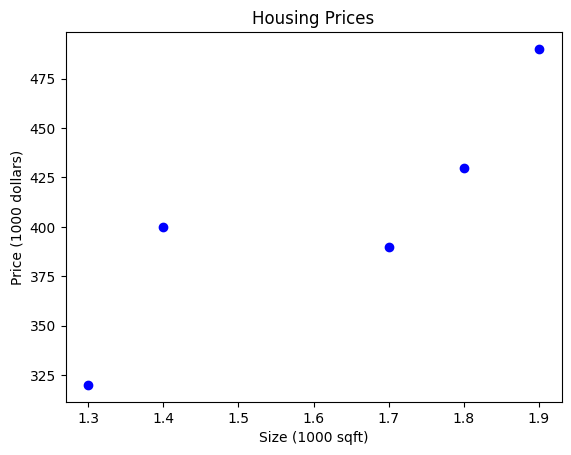

In [ ]:
# plot the data points
plt.scatter(x_train, y_train, marker = 'o', c = 'blue')

plt.title("Housing Prices")
plt.ylabel('Price (1000 dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()

### Prediction by a linear model
- Model : $y = w x + b$

In [ ]:
# Computes the prediction of a linear model
# w, b : model parameters
# x, y : scalar


def predict(x, w, b):

    # the linear model y = wx + b
    y = w*x +b

    return y

In [ ]:
# predict with arbitrary model parameter
w = 100
b = 10

print('size =     ', x_train[0])
print('price =    ', y_train[0])

# predict the y value of first data(x_train[0]) using w and b
y_hat = predict(x_train[0], w, b)

print('predicted =', y_hat)

size =      1.8
price =     430.0
predicted = 190.0


### Cost function
- Mean Squared Error
![image-4.png](attachment:image-4.png)

In [ ]:
# Computes the cost function - MSE
# x is a vector of training data (ndarray (m,))
# 각 데이터에 대해 실제값 차이를 제곱해서 평균 낸다

def compute_cost(x, y, w, b):

    # number of training examples
    m = x.shape[0]

    cost = 0
    for i in range(m):

        # compute the predicted y of each x by the linear model
        y_hat = w*x[i] + b

        # square (predicted y - true y), and add
        cost += (y_hat - y[i]) **2

    cost = (1 / (2 * m)) * cost
    return cost

In [ ]:
print('w =', w)
print('b =', b)
print('y_train =', y_train)
print('y_hat =  ', predict(x_train, w, b))

# check the cost for the model with w = 100, b = 10
cost = compute_cost(x_train, y_train, w,b)

print('--> cost =', cost)

w = 100
b = 10
y_train = [430. 320. 390. 490. 400.]
y_hat =   [190. 140. 180. 200. 150.]
--> cost = 28070.0


### Computing gradients
![image-4.png](attachment:image-4.png)
![image-5.png](attachment:image-5.png)

In [ ]:
# Compute the gradient for linear regression
# x is a vector of training data (ndarray (m,))
# dj_dw : The gradient of the cost w.r.t. the parameters w
# dj_db : The gradient of the cost w.r.t. the parameter b
# 현재 위치에서 기울기를 재는 것

def compute_gradient(x, y, w, b):

    # Number of training examples
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        # compute the predicted y
        y_hat = w*x[i] +b

        # compute the gradients
        # chain rule
        dj_dw += -(y[i]-y_hat) *x[i]
        dj_db += -(y[i] - y_hat)

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [ ]:
# check the gradients for current w, b
print('w =', w)
print('b =', b)
print('x_train =', x_train)
print('y_train =', y_train)

dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)

print('dj_dw =', dj_dw)
print('dj_db =', dj_db)

w = 100
b = 10
x_train = [1.8 1.3 1.7 1.9 1.4]
y_train = [430. 320. 390. 490. 400.]
dj_dw = -384.8
dj_db = -234.0


### Gradient descent
- Repeat ![image-2.png](attachment:image-2.png)

In [ ]:
# Performs gradient descent to fit w, b
# w와 b를 gradient와 반대 방향으로 alpha 만큼 이동시킨다
# 경사를 재고 업데이트 후 또 재는 것
# 경사 하강법 정의 alpha 학습율

def gradient_descent(x, y, w, b, alpha, num_iters):
    """
    x (ndarray (m,))  : data, m examples
    y (ndarray (m,))  : target values
    alpha (float)     : learning rate
    num_iters (int)   : number of iterations

    J_history (list)  : History of cost values
    """
    J_history = []

    for i in range(num_iters):
        # compute the gradient
        dj_dw, dj_db = compute_gradient(x,y,w,b)

        # update Parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # save cost to J_history list
        J_history.append(compute_cost(x,y,w,b))

        # print cost every 1000 iteration
        if (i % 1000) == 0:
            print('Iteration %5d: Cost %0.2e ' % (i, J_history[-1]))

    return w, b, J_history

### Linear regression by gradient descent
- Starting from initial parameters
- Use GD to get the parameters

In [ ]:
# initialize parameters
w_init = 0
b_init = 0

# set the hyper parameters, 0.01 and 10000
alpha = 0.01
iterations = 10000

# run gradient descent
w_final, b_final, J_hist = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)

# print the learned parameters
print('w =', w_final)
print('b =', b_final)

Iteration     0: Cost 7.79e+04 
Iteration  1000: Cost 3.99e+02 
Iteration  2000: Cost 3.96e+02 
Iteration  3000: Cost 3.93e+02 
Iteration  4000: Cost 3.92e+02 
Iteration  5000: Cost 3.90e+02 
Iteration  6000: Cost 3.90e+02 
Iteration  7000: Cost 3.89e+02 
Iteration  8000: Cost 3.88e+02 
Iteration  9000: Cost 3.88e+02 
w = 201.1031304050341
b = 80.34795484298294


### Plotting cost change


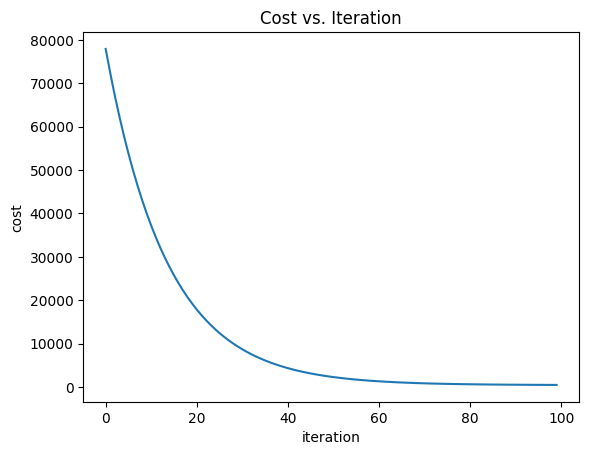

In [ ]:
# plot cost during iteration 1 ~ 100
plt.plot(J_hist[:100])

plt.title("Cost vs. Iteration")
plt.ylabel('cost')
plt.xlabel('iteration')
plt.show()

### Plotting the learned model

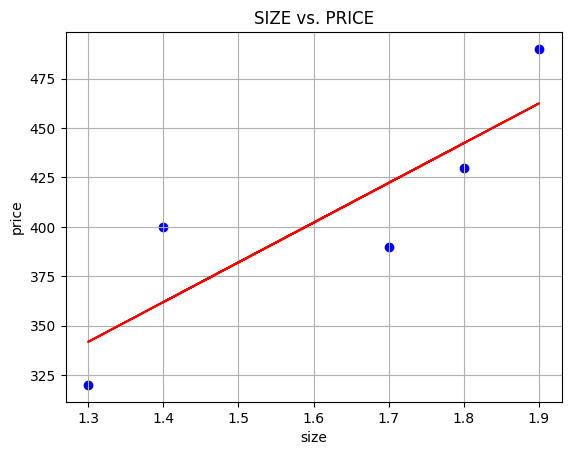

In [ ]:
# plot the data points
plt.scatter(x_train, y_train, marker='o', c='blue')

# predict the y value for x_train using learned w and b
y_hat = predict(x_train, w_final, b_final)

# show the model by plotting x_train and y_hat
plt.plot(x_train, y_hat, color ='red')

plt.title('SIZE vs. PRICE')
plt.xlabel('size')
plt.ylabel('price')
plt.grid()
plt.show()

In [ ]:
# test price prediction for 1.5 thousand sqft house
size = 1.5
price = predict(size, w_final, b_final)

print('Prediction: %.2f sqft house --> %.2f thousand dollars' % (size*1000, price))

Prediction: 1500.00 sqft house --> 382.00 thousand dollars


---

# 2. Linear Regression by gradient descent - multiple variables, vector form

### Sample dataset
- Task: predicting $ x_{0}(size), x_{1}(rooms) \rightarrow y(price)$
- Be careful! the name of dataset is X_train, not x_train!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 다중 변수
# X_train is the vector of input variables (size in 1000 square feet, number of rooms)
# y_train is the vector of target values (price in 1000s of dollars)

X_train = np.array([[1.8, 4], [1.3, 3], [1.7, 4], [1.9, 5], [1.4, 3]])
y_train = np.array([430., 320., 390., 490., 400.])

print(X_train)
print(y_train)

[[1.8 4. ]
 [1.3 3. ]
 [1.7 4. ]
 [1.9 5. ]
 [1.4 3. ]]
[430. 320. 390. 490. 400.]


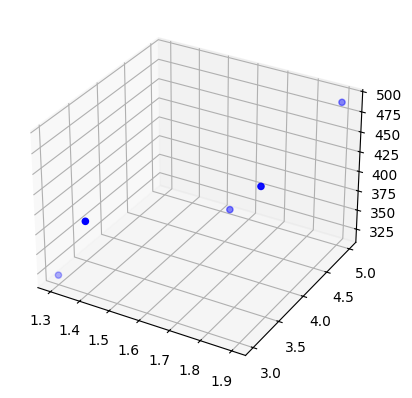

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# plot the data points in 3D
ax.scatter(X_train[:,0], X_train[:,1], y_train, marker='o', c='blue')
plt.show()

### Prediction by a linear model
- Model : $ y = \mathbf{x \cdot w} + b = w_{0} x_{0} + w_{1} x_{1} + b $

In [ ]:
# Compute the prediction of a linear model
# x : array (m, n) - m examples with n features
# y : vector (m, )
# w : model parameters (n, )
# b : model parameter scalar

def predict(x, w, b):

    # the linear model y = wx + b
    # 변수가 많아서 dot으로
    y = np.dot(x,w) + b

    return y

- Prediction - single data
![image-2.png](attachment:image-2.png)
![image-3.png](attachment:image-3.png)

In [ ]:
# arbitrary model parameter
w = np.array([100, 100])
b = 10

# first row from training data
print('X_train[0] =', X_train[0])
print('y_train[0] =', y_train[0])

# predict the y value of first data(X_train[0]) using w and b
y_hat = predict(X_train[0], w,b)

print('y_hat =     ', y_hat)

X_train[0] = [1.8 4. ]
y_train[0] = 430.0
y_hat =      590.0


- Prediction - all data
![image-2.png](attachment:image-2.png)
- Vector form
![image-3.png](attachment:image-3.png)

In [ ]:
w = np.array([100, 100])
b = 10

# all training data
print('X_train =', X_train)
print('y_train =', y_train)

# predict the y values of all data(X_train) using w and b
y_hat = predict(X_train, w,b)

print('y_hat =  ', y_hat)

X_train = [[1.8 4. ]
 [1.3 3. ]
 [1.7 4. ]
 [1.9 5. ]
 [1.4 3. ]]
y_train = [430. 320. 390. 490. 400.]
y_hat =   [590. 440. 580. 700. 450.]


### Cost function
![image-4.png](attachment:image-4.png)
- Vector form ![image-7.png](attachment:image-7.png)

In [ ]:
# Computes the cost function - MSE

def compute_cost(X, y, w, b):
    """
      X (ndarray (m,n)): dataset, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters
      b (scalar)       : model parameter
    """
    # number of training examples and number of features
    # 데이터 개수 feature 종류를 정의
    m, n = X.shape

    # compute y_hat
    y_hat = np.dot(X,w) +b

    # compute the cost
    cost = np.sum((y_hat - y) ** 2) / (2*m)

    return cost

In [ ]:
print('w =', w)
print('b =', b)
print('y_train =', y_train)
print('y_hat =  ', predict(X_train, w, b))

# check the cost for the model with w = [100, 100], b = 10
cost = compute_cost(X_train, y_train, w, b)

print('--> cost =', cost)

w = [100 100]
b = 10
y_train = [430. 320. 390. 490. 400.]
y_hat =   [590. 440. 580. 700. 450.]
--> cost = 12270.0


### Computing gradients
![image-6.png](attachment:image-6.png)
![image-7.png](attachment:image-7.png)
- Vector form
![image-8.png](attachment:image-8.png)
![image-9.png](attachment:image-9.png)

In [ ]:
# Computes the gradient for linear regression

def compute_gradient(X, y, w, b):
    """
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters
      b (scalar)       : model parameter

      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w.
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b.
    """
    # number of training examples and number of features
    m, n = X.shape

    dj_dw = np.zeros((n,))
    dj_db = 0.

    # compute y_hat
    y_hat = np.dot(X,w) +b
    err = y_hat - y

    # compute gradients
    dj_dw = np.dot(X.T, err) / m
    dj_db = np.sum(err) / m

    return dj_dw, dj_db

In [ ]:
# check the gradients for current w, b
print('w =', w)
print('b =', b)
print('X_train =', X_train)
print('y_train =', y_train)

dj_dw, dj_db = compute_gradient(X_train, y_train, w, b)

print('dj_dw =', dj_dw)
print('dj_db =', dj_db)

w = [100 100]
b = 10
X_train = [[1.8 4. ]
 [1.3 3. ]
 [1.7 4. ]
 [1.9 5. ]
 [1.4 3. ]]
y_train = [430. 320. 390. 490. 400.]
dj_dw = [247.2 592. ]
dj_db = 146.0


### Gradient descent
- Repeat ![image-3.png](attachment:image-3.png)

In [ ]:
# Performs gradient descent to fit w, b

def gradient_descent(X, y, w, b, alpha, num_iters):
    """
      X (ndarray (m,n))   : data, m examples with n features
      y (ndarray (m,))    : target values
      w (ndarray (n,)): model parameters
      b (scalar)      : model parameter
      alpha (float)       : learning rate
      num_iters (int)     : number of iterations
    """
    # a list to store cost J at each iteration
    J_history = []

    for i in range(num_iters):

        # compute the gradient
        dj_dw, dj_db = compute_gradient(X,y,w,b)

        # update Parameters
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        # save cost to J_history list
        J_history.append(compute_cost(X, y, w,b))

        # print cost every 1000 iteration
        if (i % 1000) == 0:
            print('Iteration %5d: Cost %0.2e ' % (i, J_history[-1]))

    return w, b, J_history

### Linear regression by gradient descent
- Starting from initial parameters
- Use GD to get the parameters

In [ ]:
# initialize parameters
w_init = np.zeros(X_train.shape[1])
b_init = 0.

# set the hyperparameters, 0.1 and 10000
alpha = 0.1
iterations = 10000

# run gradient descent
w_final, b_final, J_hist = gradient_descent(X_train, y_train, w_init, b_init, alpha, iterations)

# print the learned parameters
print('w =', w_final)
print('b =', b_final)

Iteration     0: Cost 6.27e+04 
Iteration  1000: Cost 3.76e+02 
Iteration  2000: Cost 3.74e+02 
Iteration  3000: Cost 3.73e+02 
Iteration  4000: Cost 3.73e+02 
Iteration  5000: Cost 3.72e+02 
Iteration  6000: Cost 3.72e+02 
Iteration  7000: Cost 3.72e+02 
Iteration  8000: Cost 3.72e+02 
Iteration  9000: Cost 3.72e+02 
w = [137.51483137  22.57217992]
b = 97.45385409256504


### Plotting cost change

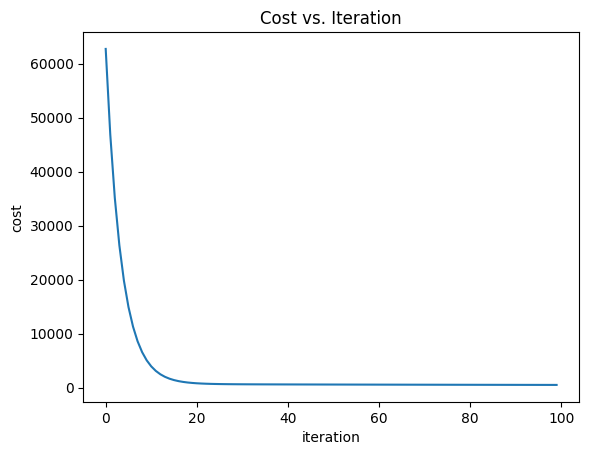

In [ ]:
# plot cost during iteration 1 ~ 100
plt.plot(J_hist[:100])

plt.title("Cost vs. Iteration")
plt.ylabel('cost')
plt.xlabel('iteration')
plt.show()

### Plotting the learned model

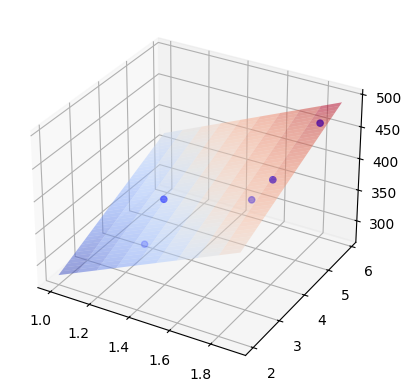

In [ ]:
from matplotlib import cm

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# plot the data points
ax.scatter(X_train[:,0], X_train[:,1], y_train, marker='o', c='blue')

# predict the y values for all meshgrid using learned w and b
x0 = np.arange(1, 2, 0.1)
x1 = np.arange(2, 6, 0.1)
x0, x1 = np.meshgrid(x0, x1)
y_hat = w_final[0] * x0 + w_final[1] * x1 + b_final

# show the model by plotting Z surface
ax.plot_surface(x0, x1, y_hat, cmap=cm.coolwarm, alpha=0.5)

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# compute y_hat for X_train
y_hat = predict(X_train, w_final, b_final)

# print the mean squared error(MSE) between y and y_hat
print('MSE : %.2f' % mean_squared_error(y_train, y_hat))

MSE : 744.62


# 3. Linear Regression using scikit learn


In [ ]:
X_train = np.array([[1.8, 4], [1.3, 3], [1.7, 4], [1.9, 5], [1.4, 3]])
y_train = np.array([430., 320., 390., 490., 400.])

print(X_train)
print(y_train)

[[1.8 4. ]
 [1.3 3. ]
 [1.7 4. ]
 [1.9 5. ]
 [1.4 3. ]]
[430. 320. 390. 490. 400.]


In [ ]:
from sklearn.linear_model import LinearRegression

# training the model - use .fit()
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# print the learned model parameters
print('w =', lr.coef_)
print('b =', lr.intercept_)

w = [138.46153846  22.30769231]
b = 96.92307692307713


In [ ]:
from sklearn.metrics import mean_squared_error

# predict y values for X - use .predict()
y_hat = lr.predict(X_train)

# print the mean squared error(MSE) between y and y_hat
print('MSE : %.2f' % mean_squared_error(y_train, y_hat))

MSE : 744.62


# 4. Polynomial Regression and Regularization

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

def true_fun(X):
    return np.cos(1.5*np.pi * X)

# sample data.
np.random.seed(0)
n_samples = 20
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

X = X.reshape(-1, 1)
print(X[:3])
print(y[:3])

[[0.0202184 ]
 [0.07103606]
 [0.0871293 ]]
[1.14487249 0.9239768  0.94819339]


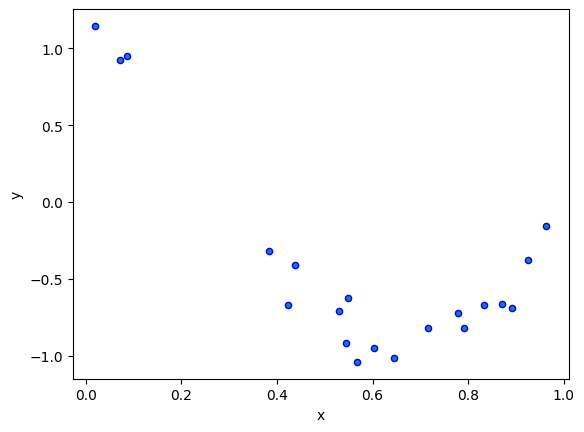

In [ ]:
# plot the data points
plt.scatter(X, y, edgecolor="b", s=20)

plt.xlabel("x")
plt.ylabel("y")
plt.show()

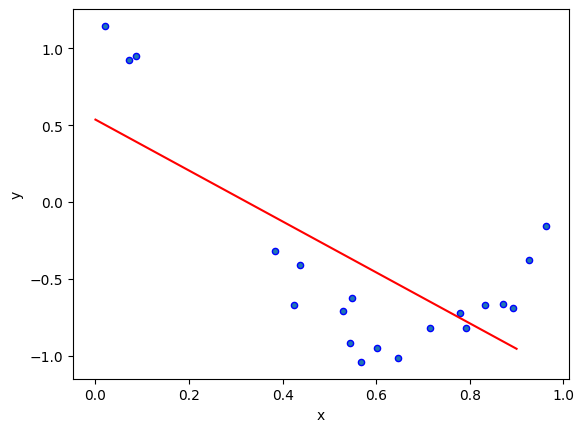

In [ ]:
# training the linear regression model with X
lr = LinearRegression()
lr.fit(X, y)

plt.scatter(X, y, edgecolor="b", s=20)

# show the model by plotting x_test and predicted values
# x축은 좌표 lr.predict는 계산된 결과를 y축에 둔다
X_test = np.arange(0, 1, 0.1).reshape(-1, 1)
plt.plot(X_test, lr.predict(X_test), c = 'red')

plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Generating polynomial features
- $x \rightarrow x, x^2, x^3, ...$

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# generate polynomial features of X. degree=10
# 차수
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

print(X_poly[:3])

[[2.02183974e-02 4.08783595e-04 8.26494919e-06 1.67104028e-07
  3.37857564e-09 6.83093851e-11 1.38110630e-12 2.79237560e-14
  5.64573598e-16 1.14147734e-17]
 [7.10360582e-02 5.04612156e-03 3.58456585e-04 2.54633428e-05
  1.80881550e-06 1.28491123e-07 9.12750292e-09 6.48381829e-10
  4.60584893e-11 3.27181353e-12]
 [8.71292997e-02 7.59151487e-03 6.61443374e-04 5.76310980e-05
  5.02135721e-06 4.37507337e-07 3.81197079e-08 3.32134345e-09
  2.89386329e-10 2.52140282e-11]]


### Polynomial regression
- $y = w_{0}x^0 + w_{1}x^1 + w_{2}x^2 + ...$
- $cost = ||y - Xw||^2_2  $

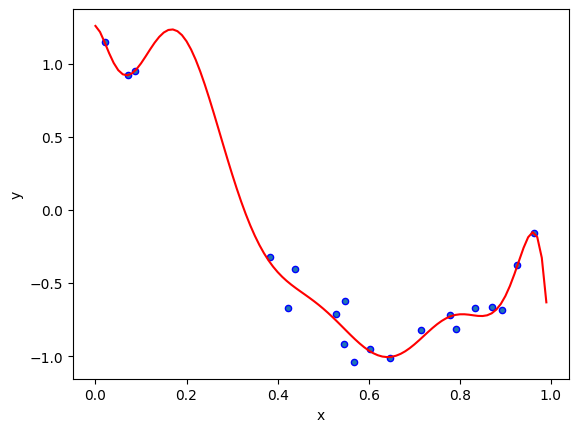

In [ ]:
# training the linear regression model with polynomial features of X
lr = LinearRegression()
lr.fit(X_poly, y)

plt.scatter(X, y, edgecolor="b", s=20)

X_test = np.arange(0, 1, 0.01).reshape(-1, 1)
# generate polynomial features of X_test
X_test_poly = poly.fit_transform(X_test)

# show the model by plotting X_test and predicted values from polynomial features of X_test
plt.plot(X_test, lr.predict(X_test_poly), c= 'r')

plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Polynomial regression with regularization
- $cost = ||y - Xw||^2_2 + \alpha * ||w||^2_2 $

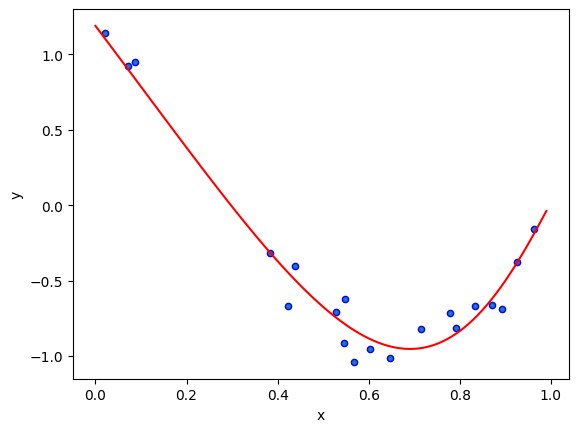

In [ ]:
# training the ridge regression model with polynomial features of X
# set regularization parameter alpha = 0.01
lr = Ridge(alpha = 0.01)
lr.fit(X_poly, y)

plt.scatter(X, y, edgecolor="b", s=20)

X_test = np.arange(0, 1, 0.01).reshape(-1, 1)
# generate polynomial features of X_test
X_test_poly = poly.fit_transform(X_test)

# show the model by plotting X_test and predicted values from polynomial features of X_test
plt.plot(X_test, lr.predict(X_test_poly), c = 'r')

plt.xlabel("x")
plt.ylabel("y")
plt.show()

---

# Quiz 1 : Linear Regression - Gradient descent

## Find a model predicting 'MEDV' from 'LSTAT' using Boston Housing Dataset
- Train linear regression model using gradient descent with X = 'MEDV'(Median value) and y = 'LSTAT'(lower status of population %)
  - Use the functions from 2. Linear Regression by gradient descent - multiple variables, vector form
- Show the learned model (parameters)
- Show the cost change during learning
- Compute the Mean Squared Error of the model
- Plot the model

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/머신러닝/Week 3 Materials/housing_data.txt", header=None, sep=r'\s+')

df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS',
              'NOX', 'RM', 'AGE', 'DIS', 'RAD',
              'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


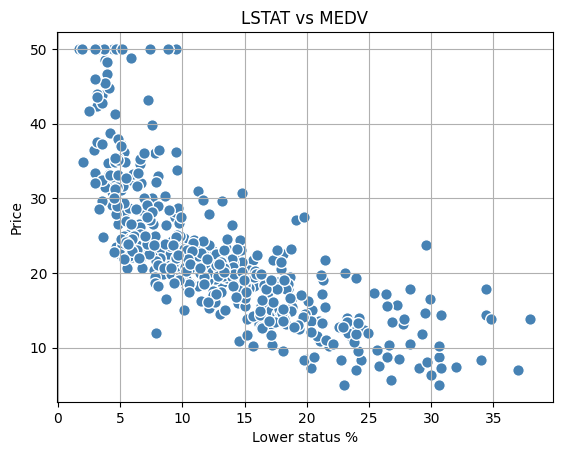

In [48]:
# plotting number of lower status(LSTAT) vs. price(MEDV)
plt.scatter(df["LSTAT"].values, df["MEDV"].values, c="steelblue", edgecolor="white", s=70)

plt.title('LSTAT vs MEDV')
plt.xlabel('Lower status %')
plt.ylabel('Price')
plt.grid()
plt.show()

In [49]:
# get X, y array from df's LSTAT, MEDV column - use .values
X = df["LSTAT"].values
y = df["MEDV"].values

# show X, y and shapes
X = X.reshape(-1, 1)
print(X[0:3])
print(X.shape)
print(y[0:3])
print(y.shape)

[[4.98]
 [9.14]
 [4.03]]
(506, 1)
[24.  21.6 34.7]
(506,)


In [50]:
# use the functions from 2. Linear Regression by gradient descent - multiple variables, vector form
# compute_cost, compute_gradient, gradient_descent

def compute_cost(X, y, w, b):
    m = X.shape[0]

    cost = 0
    for i in range(m):
        y_hat = w*X[i] + b
        cost += (y_hat - y[i]) **2

    cost = (1 / (2 * m)) * cost
    return cost
    ####### your code here #######
    #m,n = X.shape
    #y_hat = np.dot(X,w)+b
    #cost = (1/(2*m)) * np.sum((y_hat - y)**2)
    #return cost
    ##############################

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        y_hat = w*X[i] +b
        dj_dw += -(y[i]-y_hat) *X[i]
        dj_db += -(y[i] - y_hat)

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
    ####### your code here #######
    #m,n = X.shape
    #y_hat = np.dot(X,w) + b
    #err = y_hat - y
    #dj_dw = (1/m)*np.dot(X.T, err)
    #dj_db = (1/m)*np.sum(err)
    #return dj_dw, dj_db
    ##############################

def gradient_descent(X, y, w, b, alpha, num_iters):
    J_history = []

    for i in range(num_iters):

        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_history.append(compute_cost(X,y,w,b))

        if (i % 1000) == 0:
            print('Iteration %5d: Cost %0.2e ' % (i, J_history[-1]))

    return w, b, J_history
    ####### your code here ######
    #J_history = []
    #for i in range(num_iters):
    #  dj_dw, dj_db = compute_gradient(X,y,w,b)
    #  w = w-alpha*dj_dw
    # b = b-alpha*dj_db
    #  J_history.append(compute_cost(X,y,w,b))
    # if(i%1000) == 0:
    #    print('Iteration %5d: Cost %0.2e' % (i, J_history[-1]))
    #return w,b,J_history

    ##############################

In [51]:
# initialize parameters to zero
w_init = np.zeros(X.shape[1])
b_init = 0.

# set the hyperparameters. learning rate 0.001, interations 10000
alpha = 0.001
iterations = 10000

# training the model by gradient descentNone
w_final, b_final, J_hist = gradient_descent(X, y, w_init, b_init, alpha, iterations)

# print the learned parameters
print('w =', w_final)
print('b =', b_final)

/tmp/ipykernel_2064/1368563226.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Iteration %5d: Cost %0.2e ' % (i, J_history[-1]))


Iteration     0: Cost 2.45e+02 
Iteration  1000: Cost 1.08e+02 
Iteration  2000: Cost 7.41e+01 
Iteration  3000: Cost 5.31e+01 
Iteration  4000: Cost 4.02e+01 
Iteration  5000: Cost 3.22e+01 
Iteration  6000: Cost 2.73e+01 
Iteration  7000: Cost 2.42e+01 
Iteration  8000: Cost 2.23e+01 
Iteration  9000: Cost 2.11e+01 
w = [-0.76292122]
b = [31.43697229]


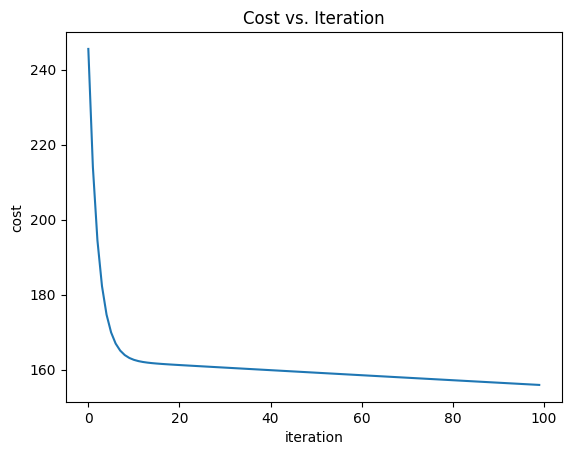

In [52]:
# plot cost during iteration 1 ~ 100
plt.plot(J_hist[:100])

plt.title('Cost vs. Iteration')
plt.ylabel('cost')
plt.xlabel('iteration')
plt.show()

In [53]:
from sklearn.metrics import mean_squared_error

# compute y_hat
y_hat = np.dot(X, w_final) + b_final

# print the mean squared error(MSE) between y and y_hat
print('MSE : %.2f' %mean_squared_error(y,y_hat))

MSE : 40.83


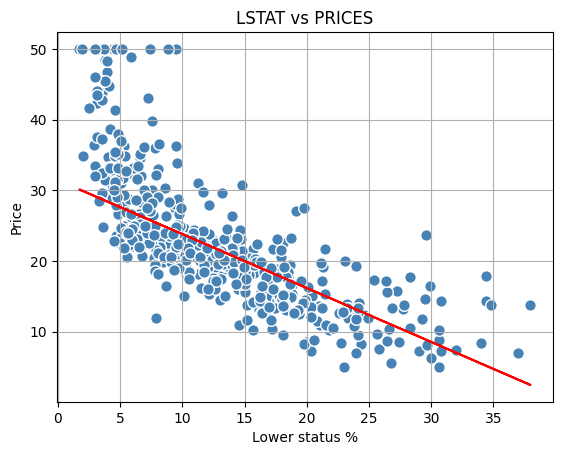

In [54]:
# plotting the data and model
plt.scatter(X, y, edgecolors = "white", c = "steelblue", s = 70)
plt.plot(X, y_hat, c='red')

plt.title('LSTAT vs PRICES')
plt.xlabel('Lower status %')
plt.ylabel('Price')
plt.grid()
plt.show()

# Quiz 2 : Linear Regression - Scikit learn

## Find a model predicting 'MEDV' from 'LSTAT' using Boston Housing Dataset
- Train linear regression model using scikit learn with X = 'MEDV'(Median value) and y = 'LSTAT'(lower status of population %)
- Show the learned model (parameters)
- Compute the Mean Squared Error of the model
- Plot the model

In [55]:
print(X[0:3])
print(X.shape)
print(y[0:3])
print(y.shape)

[[4.98]
 [9.14]
 [4.03]]
(506, 1)
[24.  21.6 34.7]
(506,)


In [56]:
from sklearn.linear_model import LinearRegression

# training the linear regression model
lr = LinearRegression()
lr.fit(X,y)

LinearRegression()

In [57]:
# print the learned model parameters
print("w =", lr.coef_)
print("b =", lr.intercept_)

w = [-0.95004935]
b = 34.5538408793831


In [58]:
from sklearn.metrics import mean_squared_error

# predict y values for X - use .predict()
y_hat = lr.predict(X)

# print the mean squared error(MSE)
print("MSE : %.2f" % mean_squared_error(y, y_hat))

MSE : 38.48


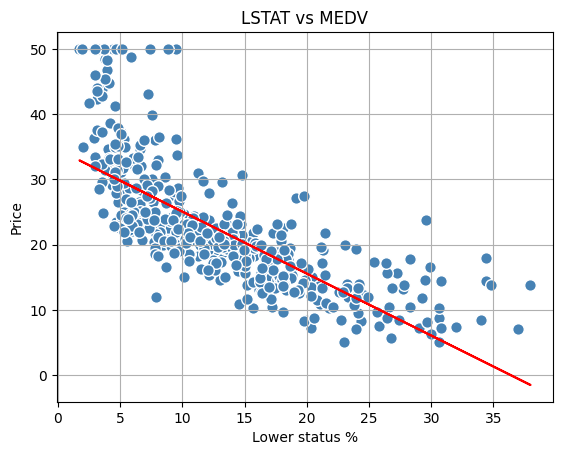

In [59]:
# plotting the data and model
plt.scatter(X, y, edgecolor="white", c="steelblue", s=70)
plt.plot(X, lr.predict(X), c='red')

plt.title('LSTAT vs MEDV')
plt.xlabel('Lower status %')
plt.ylabel('Price')
plt.grid()
plt.show()

# Quiz 3: Polynomial Regression - Scikit learn

## Find a model predicting 'MEDV' from 'LSTAT' using Boston Housing Dataset
- Train linear regression model using scikit learn with X = 'MEDV'(Median value) and y = 'LSTAT'(lower status of population %)
- Use PolynomialFeatures of degree=2 to generate ($x$, $x^2$)
- Show the learned model (parameters)
- Compute the Mean Squared Error of the model
- Plot the model

In [60]:
from sklearn.preprocessing import PolynomialFeatures

# generate polynomial features of X. degree=2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(X_poly[:3])
print(X_poly.shape)

[[ 4.98   24.8004]
 [ 9.14   83.5396]
 [ 4.03   16.2409]]
(506, 2)


In [61]:
from sklearn.linear_model import LinearRegression

# training the linear regression model with polynomial features of X
lr = LinearRegression()
lr.fit(X_poly, y)

LinearRegression()

In [62]:
# print the learned model parameters
print('w = ', lr.coef_)
print('b = ', lr.intercept_)

w =  [-2.3328211   0.04354689]
b =  42.86200732816936


In [63]:
from sklearn.metrics import mean_squared_error

# predict y values for X - use .predict()
y_hat = lr.predict(X_poly)

# print the mean squared error(MSE)
print('MSE : %.2f' % mean_squared_error(y, y_hat))

MSE : 30.33


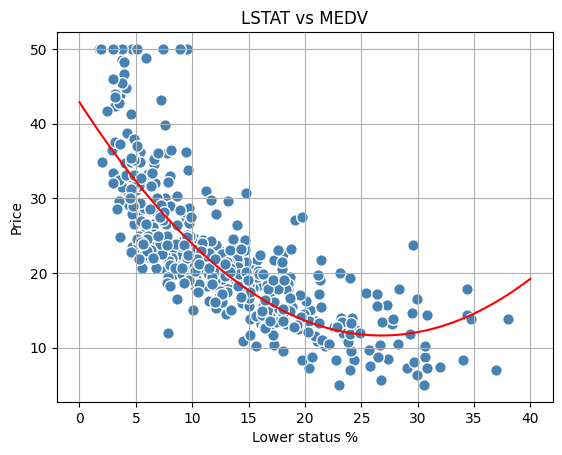

In [64]:
# plotting the data
plt.scatter(X, y, edgecolor = "white", c = "steelblue", s = 70)

# show the model by plotting X_test and predicted values from polynomial features of X_test
X_test = np.arange(0, 40, 0.01).reshape(-1, 1)
X_test_poly = poly.fit_transform(X_test)
plt.plot(X_test, lr.predict(X_test_poly), c='red')

plt.title('LSTAT vs MEDV')
plt.xlabel('Lower status %')
plt.ylabel('Price')
plt.grid()
plt.show()